## Preliminaries

### Import statements

In [ ]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
import ccc2026
from ccc2026.config import CONFIG

### Global values

See `src/ccc2026/config.py`

In [ ]:
# local directory structure
plot_dir = CONFIG["plot_dir"]

# Initialize random number generator
seed = 1
rng = np.random.default_rng(seed)

### Load tokens

In [ ]:
ccc2026.setup()
tokens = ccc2026.tokens

### Select most frequent lemmas

In [7]:
# corpus-wide count for all non-punctuation lemmas, from most frequent to least
corpus_lemma_count = tokens["lemma"].value_counts()

# a list of the top lemmas
top_lemmas = corpus_lemma_count.head(100).index

# show results
display(corpus_lemma_count.loc[top_lemmas])

lemma
δέ        21339
καί       13671
ὁ          9589
τε         5574
ἐγώ        3783
          ...  
πέλω        530
τίθημι      530
ἄγω         525
σύν         520
βαίνω       519
Name: count, Length: 100, dtype: int64

### Labels

Label each token by author (= work title for now) and by speech/narrative (what do we call this?)

In [8]:
# Narratological groups
nr_mask = tokens["speaker"].isna()
sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

# default group is "other"
nara_group_ids = pd.Series("oth", index=tokens.index)
nara_group_ids[nr_mask] = "nar"
nara_group_ids[sp_mask] = "spk"

# Authorship groups
auth_group_ids = tokens["work"].str.slice(0,4)

# Combined two-factor group
group_ids = auth_group_ids + "-" + nara_group_ids

## Authorship

### Define samples

In [14]:
# sample labels are just work title + book number
tokens["sample_id"] = tokens["work"] + " " + tokens["line_id"].str.split("_", expand=True).iloc[:,0]

In [17]:
tokens

,author,title,work,urn,line_id,text,lemma,pos,verbform,mood,...,gender,speech_id,speaker,addressee,level,type,cluster,turn,tags,sample_id
0,Tryphiodorus,Ἅλωσις Ἰλίου,Sack of Troy,urn:cts:greekLit:tlg0647.tlg001.perseus-grc2:1,00_0001,τέρμα,τέρμα,NOUN,NaN,NaN,...,Neut,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Sack of Troy 00
1,Tryphiodorus,Ἅλωσις Ἰλίου,Sack of Troy,urn:cts:greekLit:tlg0647.tlg001.perseus-grc2:1,00_0001,πολυκμήτοιο,πολυκμήτοιο,ADJ,NaN,NaN,...,Masc,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Sack of Troy 00
2,Tryphiodorus,Ἅλωσις Ἰλίου,Sack of Troy,urn:cts:greekLit:tlg0647.tlg001.perseus-grc2:1,00_0001,μεταχρόνιον,μεταχρόνιος,ADJ,NaN,NaN,...,Masc,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Sack of Troy 00
3,Tryphiodorus,Ἅλωσις Ἰλίου,Sack of Troy,urn:cts:greekLit:tlg0647.tlg001.perseus-grc2:1,00_0001,πολέμοιο,πόλεμος,NOUN,NaN,NaN,...,Masc,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Sack of Troy 00
4,Tryphiodorus,Ἅλωσις Ἰλίου,Sack of Troy,urn:cts:greekLit:tlg0647.tlg001.perseus-grc2:2,00_0002,καὶ,καί,CCONJ,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Sack of Troy 00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87160,Homer,Ὀδύσσεια,Odyssey,urn:cts:greekLit:tlg0012.tlg002.perseus-grc2:2...,24_0548,ἠμὲν,ἠμέν,SCONJ,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Odyssey 24
87161,Homer,Ὀδύσσεια,Odyssey,urn:cts:greekLit:tlg0012.tlg002.perseus-grc2:2...,24_0548,δέμας,δέμας,NOUN,NaN,NaN,...,Neut,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Odyssey 24
87162,Homer,Ὀδύσσεια,Odyssey,urn:cts:greekLit:tlg0012.tlg002.perseus-grc2:2...,24_0548,ἠδὲ,ἠδέ,CCONJ,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Odyssey 24
87163,Homer,Ὀδύσσεια,Odyssey,urn:cts:greekLit:tlg0012.tlg002.perseus-grc2:2...,24_0548,καὶ,καί,ADV,NaN,NaN,...,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Odyssey 24


### Tokens per sample

Distribution of book lengths in tokens. This is just to give me a sense of how diverse our samples are. The longest are the four books of Apollonius' *Argonautica*.

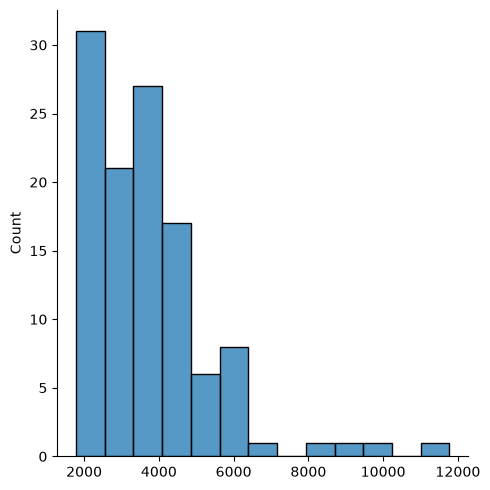

In [15]:
tokens_per_sample = tokens.groupby("sample_id").size()
sns.displot(tokens_per_sample)
plt.show()

### Generate feature vectors by book

In [16]:
# tally lemma counts
samples = pd.crosstab(
    tokens.loc[tokens["lemma"].isin(top_lemmas), "sample_id"],
    tokens.loc[tokens["lemma"].isin(top_lemmas), "lemma"],
)

# normalize as freq / 1000 words
samples = samples.div(tokens_per_sample, axis=0) * 1000

display(samples)

ValueError: cannot reindex on an axis with duplicate labels

### Dimensionality reduction

In [ ]:
model = PCA(n_components=3)
scaled = StandardScaler().fit_transform(samples)
pca = pd.DataFrame(model.fit_transform(scaled), columns=["PC1", "PC2", "PC3"])

## Author signal
### plot individual books

This is the plot that I might start with, showing how the different books cluster themselves according to author/work based on the most frequent words.


In [ ]:
# Labels for legend: take first 4 chars of index (e.g. "Iliad" -> "Ilia")
short_label = samples.index.str.slice(0,4)

# Custom order for labels in the legend (top to bottom)
label_order = ["Ilia", "Odys", "Argo", "Post", "Sack", "Dion"]

# Plot using Seaborn
g = sns.relplot(data=pca,
    x = "PC1",
    y = "PC2",
    hue = short_label,        # color points by work
    hue_order = label_order,
    palette = "deep",         # seaborn color palette; try "muted", "bright", "colorblind", etc.
)

# Figure dimensions in inches (width, height)
g.figure.set_size_inches(7, 4)

# Set figure title
g.ax.set_title(f"individual books, {len(samples.columns)} top lemmas")

# Set legend heading
g._legend.set_title("Work")

# Export figure as png file
g.savefig(os.path.join(plot_dir, "auth_PCA_by_book.png"),
    # dpi=300,              # uncomment for higher resolution (default 100)
    # bbox_inches="tight",  # uncomment to trim whitespace around figure
)

plt.show()

## Speech vs. Narrative

This part shows the speech/narrative signal by averaging out authorship. We randomly sample 1000 tokens at a time from the corpus as a whole, according only to whether they are narrative or speech.

### Create new samples

In [ ]:
# create samples
sample_size = 1000
for group in nara_group_ids.unique():
    n_toks = sum(nara_group_ids==group)
    tokens.loc[nara_group_ids==group, "sample_id"] = (rng.permutation(n_toks) // sample_size).astype(str)
tokens["sample_id"] = nara_group_ids + "-" + tokens["sample_id"].map(str)

### Tokens per sample

In [ ]:
tokens_per_sample = tokens.groupby("sample_id").size()
sns.displot(tokens_per_sample)

### Calculate feature vectors for each sample

As in the author signal plot above, we're using the same top 100 words.

In [ ]:
# tally lemma counts
samples = pd.crosstab(
    tokens.loc[tokens["lemma"].isin(top_lemmas), "sample_id"],
    tokens.loc[tokens["lemma"].isin(top_lemmas), "lemma"],
)

# normalize as freq / 1000 words
samples = samples.div(tokens_per_sample, axis=0) * 1000

display(samples)

### Dimensionality reduction

In [ ]:
model = PCA(n_components=3)
scaled = StandardScaler().fit_transform(samples)
pca = pd.DataFrame(model.fit_transform(scaled), columns=["PC1", "PC2", "PC3"])

### Plot

In [ ]:
# Labels for legend: take first 3 chars of index
short_label = samples.index.str.slice(0,3)

# Custom order for labels in the legend (top to bottom)
label_order = ["nar", "spk", "oth"]

# Plot using Seaborn
g = sns.relplot(data=pca,
    x = "PC1",
    y = "PC2",
    hue = short_label,        # color points by work
    hue_order = label_order,
    palette = "deep",         # seaborn color palette; try "muted", "bright", "colorblind", etc.
)

# Figure dimensions in inches (width, height)
g.figure.set_size_inches(7, 4)

# Set figure title
g.ax.set_title(f"Random samples of 1000 tokens, {len(samples.columns)} top lemmas")

# Set legend heading
g._legend.set_title("Text Class")

# Export figure as png file
g.savefig(os.path.join(plot_dir, "spk-nar_PCA_by_book.png"),
    # dpi=300,              # uncomment for higher resolution (default 100)
    # bbox_inches="tight",  # uncomment to trim whitespace around figure
)

plt.show()

## Speech-like words per author

For each work × class (e.g. `Ilia-spk`, `Ilia-nar`), we compute the relative frequency of each of the top 100 lemmas (per 1000 words), then **z-score across the 100 lemmas within each profile** (`axis=1`) rather than across works for a given lemma. This rescales each profile so it reflects which lemmas are over- or under-represented relative to that profile's own overall lemma distribution.

Taking spk − nar for each author then highlights lemmas whose *relative* prominence shifts between speech and narrative, which is what the ranked tables below show.

In [ ]:
# calculate frequencies
freq = pd.crosstab(group_ids, tokens["lemma"], normalize="index") * 1000

# remove apologue
freq = freq.loc[~(freq.index=="Odys-oth"), top_lemmas]

# calculate z-scores
scaled = pd.DataFrame(zscore(freq, axis=1), index=freq.index, columns=freq.columns)

# take difference between spk and nar for each author
mask = scaled.index.str.endswith("spk")
masked_names = scaled[mask].index.str.slice(0,4)
assert masked_names.equals(scaled[~mask].index.str.slice(0,4))

diff_scaled = scaled[mask].reset_index(drop=True) - scaled[~mask].reset_index(drop=True)
diff_scaled.index = masked_names
diff_scaled.index.name = "work"
display(diff_scaled)

#### Table of top words per author, for export

In [ ]:
def show_top_lemmas_per_work(n=10, show_scores=False):
    '''Generate a table of top speech/narrative lemmas'''
    
    works = ["Ilia", "Odys", "Argo", "Post", "Sack", "Dion"]

    if show_scores:
        return pd.DataFrame(
            {work: [f"{lem} ({val:.2f})"
            for lem, val in diff_scaled.loc[work].sort_values(ascending=False).head(n).items()]
                 for work in works},
            index=range(1, n + 1)
        )
    else:
        return pd.DataFrame(
            {work: diff_scaled.loc[work].sort_values(ascending=False).head(n).index
                 for work in works},
            index=range(1, n + 1)
        )

show_top_lemmas_per_work(show_scores=True)